# 02 — Attribution и ROMI

Продолжение `01_sales_layer.ipynb`. На вход идёт `outputs/orders.csv` — 628 заказов,
собранных из реальных продаж.

## Про данные: что реальное, а что нет

Это главное, что нужно прочитать перед остальным кодом.

| Слой | Источник | Статус |
|---|---|---|
| Заказы, выручка, даты | `base.xlsx` от организаторов | **реальные** |
| Реестр размещений: каналы, даты, подписчики, просмотры | собран командой через TGStat и публичный Telegram | **реальные** |
| Стоимость размещений (`cost`) | восстановлена по CPM, журнала закупок не существует | **синтетика** |
| Касания пользователей (`touches`) | сгенерированы по известному маркетинговому календарю | **синтетика** |

Причина, по которой касания приходится генерировать, сформулирована в условии кейса:
Поступашки исторически не логировали источники пользователей. Этих данных нет не потому,
что мы их не нашли, а потому что они никогда не собирались.

**Что из этого следует для чтения результатов.** Распределение выручки по каналам ниже — это
свойство генератора касаний, а не факт о бизнесе. Вывод «канал X принёс N рублей» из этого
ноутбука делать нельзя. Проверяемое здесь другое: что пайплайн
`заказы + реестр + касания → attribution → ROMI` работает, воспроизводим и даёт разные
ответы при разных допущениях. Как только бот начнёт писать реальные `bot_start` с `source`,
синтетический слой заменяется на реальный без изменения кода.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})

CANDIDATES = [Path("../outputs"), Path("outputs")]
OUT = next(p for p in CANDIDATES if p.exists())

orders = pd.read_csv(OUT / "orders.csv", parse_dates=["ts"])
orders["date"] = orders["ts"].dt.date
print(f"заказов: {len(orders)}, выручка: {orders.revenue.sum():,.0f} ₽".replace(",", " "))
print(f"из них повторных: {orders.is_repeat.sum()} "
      f"({orders.loc[orders.is_repeat, 'revenue'].sum() / orders.revenue.sum():.1%} выручки)")
orders.head(3)

заказов: 625  выручка: 5 904 672 ₽
из них повторных: 19 (2.8% выручки)


,order_id,student_id,ts,revenue,n_items,courses,seq,is_repeat,date
0,O0001,437,2026-08-04 09:08:31,16840.0,2,ML про + Аналитика старт,1,False,2026-08-04
1,O0002,443,2026-08-04 10:14:38,16950.0,2,Линейная алгебра + Мат анализ,1,False,2026-08-04
2,O0003,430,2026-08-04 13:38:06,8950.0,1,К ВУЗу,1,False,2026-08-04


## 1. Реестр размещений

Каналы, даты и охваты — реальные, собраны командой. Всё, что удалось найти, приходится
на 8–9 августа: это единственное окно, по которому есть внешние упоминания.

То, что упоминания нашлись только здесь, само по себе результат: по всплескам 22–24 августа
и 4–6 сентября внешней активности в открытых источниках не обнаружено, значит объяснять их
закупкой рекламы нельзя.

In [2]:
registry = pd.DataFrame([
    # дата,        канал,              url,                        подписчики, просмотры, тип,      статус
    ("2026-08-08", "chad_protocol",    "t.me/chad_protocol/510",    10913, 6855, "post",   "ok"),
    ("2026-08-08", "postypashki_mems", "t.me/postypashki_mems/1373", 5836, 1837, "repost", "ok"),
    ("2026-08-08", "analytess",        "tgstat/@analytess/925",      3478, 1216, "repost", "deleted"),
    ("2026-08-08", "zadachi_ds",       "t.me/zadachi_ds/389",        8078, 4481, "post",   "ok"),
    ("2026-08-08", "codeof_art",       "t.me/codeof_art/306",        2059,  498, "repost", "ok"),
    ("2026-08-08", "algoses",          "t.me/algoses/594",          11974, 1328, "repost", "ok"),
    ("2026-08-08", "matesha_shad",     "tgstat/@matesha_shad/373",   5008, 1757, "repost", "deleted"),
    ("2026-08-08", "zadachi_ds",       "tgstat/@zadachi_ds/390",     8077, 4481, "repost", "deleted"),
    ("2026-08-09", "zadachi_ds",       "tgstat/@zadachi_ds/392",     8097, 2108, "repost", "ok"),
], columns=["date", "channel", "url", "subscribers", "views", "post_type", "status"])

registry["date"] = pd.to_datetime(registry["date"])
registry["placement_id"] = [f"P{i + 1:03d}" for i in range(len(registry))]

print(f"размещений: {len(registry)}, суммарный охват: {registry.views.sum():,} просмотров"
      .replace(",", " "))
registry

размещений: 9  суммарный охват: 24 561 просмотров


,date,channel,url,subscribers,views,post_type,status,placement_id
0,2026-08-08,chad_protocol,t.me/chad_protocol/510,10913,6855,post,ok,P001
1,2026-08-08,postypashki_mems,t.me/postypashki_mems/1373,5836,1837,repost,ok,P002
2,2026-08-08,analytess,tgstat/@analytess/925,3478,1216,repost,deleted,P003
3,2026-08-08,zadachi_ds,t.me/zadachi_ds/389,8078,4481,post,ok,P004
4,2026-08-08,codeof_art,t.me/codeof_art/306,2059,498,repost,ok,P005
5,2026-08-08,algoses,t.me/algoses/594,11974,1328,repost,ok,P006
6,2026-08-08,matesha_shad,tgstat/@matesha_shad/373,5008,1757,repost,deleted,P007
7,2026-08-08,zadachi_ds,tgstat/@zadachi_ds/390,8077,4481,repost,deleted,P008
8,2026-08-09,zadachi_ds,tgstat/@zadachi_ds/392,8097,2108,repost,ok,P009


### Стоимость — синтетическая

Журнала закупок не существует, поэтому `cost` восстанавливается по рыночному CPM.
Модель максимально примитивная и это намеренно: любое усложнение здесь добавляет допущений,
не добавляя знания.

- оплаченный пост: 500 ₽ за 1000 просмотров;
- взаимный репост: 150 ₽ за 1000 просмотров — репосты обычно дешевле или бартерные,
  но нулевую стоимость ставить нельзя, иначе ROMI обращается в бесконечность.

Числа CPM — единственное, что придётся заменить, когда у бизнеса появится реальный реестр.
Всё остальное в ноутбуке от них не зависит.

In [3]:
CPM = {"post": 500, "repost": 150}   # ₽ за 1000 просмотров — ДОПУЩЕНИЕ

registry["cost"] = (registry.views / 1000 * registry.post_type.map(CPM)).round(0)

print(f"суммарный синтетический бюджет: {registry.cost.sum():,.0f} ₽".replace(",", " "))
registry.groupby("channel").agg(
    размещений=("placement_id", "size"),
    просмотры=("views", "sum"),
    cost=("cost", "sum"),
).sort_values("cost", ascending=False)

суммарный синтетический бюджет: 7 652 ₽


,размещений,просмотры,cost
channel,,,
chad_protocol,1,6855,3428.0
zadachi_ds,3,11070,3228.0
postypashki_mems,1,1837,276.0
matesha_shad,1,1757,264.0
algoses,1,1328,199.0
analytess,1,1216,182.0
codeof_art,1,498,75.0


## 2. Генерация касаний

Самая уязвимая часть решения, поэтому генератор написан так, чтобы его допущения можно было
прочитать и оспорить построчно.

Касания не случайны — они воспроизводят маркетинговый календарь, восстановленный в ноутбуке 01:

| Канал касания | Когда | Основание |
|---|---|---|
| `external:<channel>` | 8–9 августа + 3 дня затухания | реальные размещения из реестра |
| `own_channel` | весь период | 43 тыс. подписчиков, основной канал продаж |
| `discount_aug` | 8–11 августа | зафиксированное падение цен на линейку «старт» |
| `launch_ai_agents` | 22–24 августа | первая продажа AI агенты 22.08 |
| (нет касаний) | — | заказ уйдёт в `organic` |

Вероятность внешнего касания распределена между размещениями пропорционально просмотрам:
канал с большим охватом чаще попадает в историю пользователя. Это единственное содержательное
допущение генератора, и оно же — то место, где attribution становится циклической:
мы сами вложили связь «охват → касание», поэтому обнаружить её в результате не достижение.

In [4]:
RNG = np.random.default_rng(42)      # фиксируем seed — ноутбук воспроизводим

# --- параметры генератора (все до одного — допущения) ---
P_OWN_CHANNEL   = 0.55   # доля заказов с касанием собственного канала
P_EXTERNAL      = 0.35   # доля заказов в окне размещений, получивших внешнее касание
EXTERNAL_DECAY  = 3      # сколько дней после публикации касание ещё возможно
DISCOUNT_WINDOW = ("2026-08-08", "2026-08-11")
LAUNCH_WINDOW   = ("2026-08-22", "2026-08-24")

rows = []

for o in orders.itertuples():
    # 1. собственный канал: пользователь читает его и видит продающие посты
    if RNG.random() < P_OWN_CHANNEL:
        lag = RNG.integers(0, 10)
        rows.append((o.student_id, o.order_id, "own_channel",
                     o.ts - pd.Timedelta(days=int(lag), hours=int(RNG.integers(0, 12)))))

    # 2. внешние размещения — только если заказ попал в окно их действия
    live = registry[(registry.date <= o.ts) &
                    (o.ts <= registry.date + pd.Timedelta(days=EXTERNAL_DECAY))]
    if len(live) and RNG.random() < P_EXTERNAL:
        pick = live.sample(1, weights=live.views, random_state=int(RNG.integers(1e9))).iloc[0]
        rows.append((o.student_id, o.order_id, f"external:{pick.channel}",
                     pick.date + pd.Timedelta(hours=int(RNG.integers(1, 48)))))

    # 3. акция на линейку «старт»
    if pd.Timestamp(DISCOUNT_WINDOW[0]) <= o.ts <= pd.Timestamp(DISCOUNT_WINDOW[1]):
        rows.append((o.student_id, o.order_id, "discount_aug",
                     o.ts - pd.Timedelta(hours=int(RNG.integers(1, 36)))))

    # 4. запуск AI агенты
    if pd.Timestamp(LAUNCH_WINDOW[0]) <= o.ts <= pd.Timestamp(LAUNCH_WINDOW[1]):
        rows.append((o.student_id, o.order_id, "launch_ai_agents",
                     o.ts - pd.Timedelta(hours=int(RNG.integers(1, 48)))))

touches = pd.DataFrame(rows, columns=["student_id", "seed_order", "channel", "ts"])
touches = touches[touches.ts >= orders.ts.min() - pd.Timedelta(days=14)]
touches["touch_id"] = [f"T{i + 1:05d}" for i in range(len(touches))]
touches = touches[["touch_id", "student_id", "channel", "ts"]].sort_values("ts")

print(f"сгенерировано касаний: {len(touches)}")
print(f"пользователей с хотя бы одним касанием: {touches.student_id.nunique()} "
      f"из {orders.student_id.nunique()}")
touches.channel.value_counts().to_frame("касаний")

сгенерировано касаний: 591
пользователей с хотя бы одним касанием: 422 из 606


,касаний
channel,
own_channel,343
discount_aug,132
launch_ai_agents,65
external:zadachi_ds,24
external:chad_protocol,18
external:postypashki_mems,4
external:algoses,2
external:codeof_art,1
external:analytess,1


## 3. Движок атрибуции

Две модели и параметр окна. Логика одна для обеих: берём все касания пользователя, попавшие
в интервал `[покупка − окно, покупка]`, и распределяем между ними выручку заказа.

- **last touch** — вся выручка последнему касанию. Baseline, который просят организаторы.
- **linear** — поровну между всеми касаниями в окне. Служит проверкой чувствительности:
  если выводы при linear переворачиваются, значит они держатся на одной модели, а не на данных.

**Повторные заказы играют по другим правилам.** Покупка от уже привлечённого клиента не может
быть заслугой платного размещения — за этого человека уже заплатили при первой покупке.
Поэтому внешние касания по заказам с `is_repeat` отбрасываются: такой заказ может достаться
собственному каналу или акции, а если и их не было — уходит в `repeat_customer`.
Это граница между acquisition и retention, и она же даёт чистый знаменатель для ROMI.

Остальные заказы без касаний в окне не выбрасываются, а уходят в канал `organic`. Это принципиально:
у Поступашек 43 тысячи подписчиков и покупает во многом существующая аудитория, поэтому
органический спрос — не остаток, а отдельная измеряемая величина. Если её молча растворить
по рекламным каналам, ROMI окажется завышенным, и это первое, что заметит жюри.

In [5]:
def attribute(orders, touches, window_days, model="last_touch"):
    """Возвращает выручку, распределённую по каналам касаний."""
    pairs = orders[["order_id", "student_id", "ts", "revenue", "is_repeat"]].merge(
        touches[["touch_id", "student_id", "channel", "ts"]],
        on="student_id", suffixes=("_order", "_touch"),
    )
    lag = (pairs.ts_order - pairs.ts_touch).dt.total_seconds() / 86400
    pairs = pairs[(lag >= 0) & (lag <= window_days)].copy()
    pairs["lag_days"] = lag[pairs.index]

    # платное размещение не может привлечь того, кто уже куплен:
    # по повторным заказам внешние касания не участвуют в дележе
    pairs = pairs[~(pairs.is_repeat & pairs.channel.str.startswith("external:"))]

    if model == "last_touch":
        idx = pairs.groupby("order_id").ts_touch.idxmax()
        won = pairs.loc[idx].copy()
        won["attributed"] = won.revenue
    elif model == "linear":
        won = pairs.copy()
        won["attributed"] = won.revenue / won.groupby("order_id").order_id.transform("size")
    else:
        raise ValueError(model)

    # заказы, до которых не дотянулось ни одно допустимое касание
    orphan_ids = set(orders.order_id) - set(pairs.order_id)
    orphans = orders[orders.order_id.isin(orphan_ids)].assign(
        channel=lambda d: np.where(d.is_repeat, "repeat_customer", "organic"),
        attributed=lambda d: d.revenue,
    )[["order_id", "channel", "attributed"]]

    result = pd.concat([won[["order_id", "channel", "attributed"]], orphans], ignore_index=True)
    assert abs(result.attributed.sum() - orders.revenue.sum()) < 1, "выручка потеряна"
    return result


demo = attribute(orders, touches, window_days=14, model="last_touch")
print(f"last touch, окно 14 дней — строк в результате: {len(demo)}")
demo.groupby("channel").attributed.sum().sort_values(ascending=False).to_frame("выручка, ₽").round(0)

last touch, окно 14 дней — строк в результате: 625


,"выручка, ₽"
channel,
own_channel,2450958.0
organic,1821915.0
discount_aug,839903.0
launch_ai_agents,609845.0
repeat_customer,56000.0
external:chad_protocol,54930.0
external:zadachi_ds,41770.0
external:postypashki_mems,19450.0
external:analytess,9900.0


Ассерт в конце функции важнее, чем кажется: он гарантирует, что при любом окне и любой модели
сумма распределённой выручки в точности равна фактической. Это первое, что стоит проверять
в любой attribution-логике — выручка не должна ни теряться, ни задваиваться.

## 4. Три окна атрибуции

Организаторы в задаче 6 просят обосновать окно. Вместо того чтобы выбрать число и защищать его,
прогоняем три и смотрим, что меняется.

- **7 дней** — короткое окно, ловит только недавние касания;
- **14 дней** — компромисс: три всплеска продаж длятся по 3 дня, между ними 10–14 дней затишья,
  так что 14 накрывает событие с затуханием, но не склеивает соседние;
- **37 дней** — вся история целиком, окно фактически перестаёт отсекать что-либо.

In [6]:
WINDOWS = [7, 14, 37]
MODELS = ["last_touch", "linear"]

runs = []
for w in WINDOWS:
    for m in MODELS:
        r = attribute(orders, touches, window_days=w, model=m)
        r = r.groupby("channel").attributed.sum().reset_index()
        r["window_days"], r["model"] = w, m
        runs.append(r)

attributed = pd.concat(runs, ignore_index=True)

pivot = attributed[attributed.model == "last_touch"].pivot_table(
    index="channel", columns="window_days", values="attributed"
).fillna(0).round(0)
pivot["Δ 7→37, ₽"] = (pivot[37] - pivot[7]).round(0)
pivot.sort_values(14, ascending=False)

window_days,7,14,37,"Δ 7→37, ₽"
channel,,,,
own_channel,1828233.0,2450958.0,2470658.0,642425.0
organic,2437890.0,1821915.0,1821915.0,-615975.0
discount_aug,839903.0,839903.0,866753.0,26850.0
launch_ai_agents,609845.0,609845.0,609845.0,0.0
repeat_customer,62750.0,56000.0,9450.0,-53300.0
external:chad_protocol,54930.0,54930.0,54930.0,0.0
external:zadachi_ds,41770.0,41770.0,41770.0,0.0
external:postypashki_mems,19450.0,19450.0,19450.0,0.0
external:analytess,9900.0,9900.0,9900.0,0.0


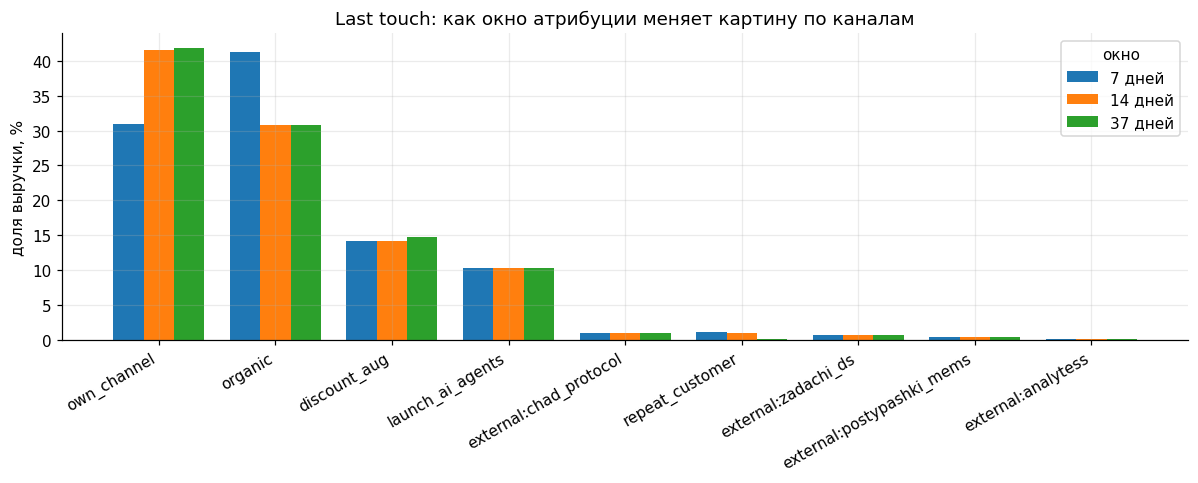

In [7]:
share = attributed[attributed.model == "last_touch"].copy()
share["pct"] = share.attributed / share.groupby("window_days").attributed.transform("sum") * 100

fig, ax = plt.subplots(figsize=(11, 4.5))
chans = share.groupby("channel").pct.mean().sort_values(ascending=False).index
x = np.arange(len(chans))
for i, w in enumerate(WINDOWS):
    s = share[share.window_days == w].set_index("channel").reindex(chans).pct.fillna(0)
    ax.bar(x + (i - 1) * 0.26, s.values, width=0.26, label=f"{w} дней")
ax.set_xticks(x)
ax.set_xticklabels(chans, rotation=30, ha="right")
ax.set_ylabel("доля выручки, %")
ax.set_title("Last touch: как окно атрибуции меняет картину по каналам")
ax.legend(title="окно")
plt.tight_layout()
plt.show()

In [8]:
organic = attributed[attributed.channel == "organic"].pivot_table(
    index="model", columns="window_days", values="attributed"
)
total = orders.revenue.sum()
print("доля выручки, оставшейся органической:\n")
print((organic / total * 100).round(1).to_string())

доля выручки, оставшейся органической:

window_days    7     14    37
model                        
last_touch   41.3  30.9  30.9
linear       41.3  30.9  30.9


Вот главное, ради чего окно вообще делалось параметром: при расширении с 7 до 37 дней
органика сжимается, и вся её выручка перетекает в рекламные каналы. Никакой новой информации
при этом не появилось — просто окно дотянулось до касаний, которые были раньше.

Практический вывод для защиты: **чем шире окно, тем выше окажется ROMI — при тех же самых
данных**. Поэтому окно нельзя выбирать после того, как посмотрел на результат; его надо
фиксировать заранее и предъявлять вместе с цифрой.

Мы фиксируем 14 дней как основной сценарий, 7 и 37 показываем как границы чувствительности.

Обрати внимание, что строки `last_touch` и `linear` совпадают. Это не ошибка: доля
органики по построению зависит только от окна — заказ уходит в `organic` тогда и только тогда,
когда в окне нет ни одного касания, а какая модель распределяла бы выручку, значения не имеет.

## 5. ROMI

```
ROMI = (Attributed Revenue − Marketing Cost) / Marketing Cost
```

Считается только для внешних размещений — только у них есть закупочная стоимость.
`own_channel`, `discount_aug`, `launch_ai_agents` и `organic` имеют нулевой cost: это
собственные активности, деления на них не существует. Их выручка показывается отдельно,
а не размазывается по рекламе.

In [9]:
cost_by_channel = (registry.groupby("channel").cost.sum()
                   .rename(lambda c: f"external:{c}"))

def romi_table(window_days, model="last_touch"):
    a = attributed[(attributed.window_days == window_days) & (attributed.model == model)]
    a = a.set_index("channel").attributed
    # reindex по ВСЕМ размещениям реестра: канал, не получивший ни одной
    # атрибутированной покупки, — это не отсутствующая строка, а ROMI = -1
    ext = (a[a.index.str.startswith("external:")]
           .reindex(cost_by_channel.index).fillna(0)
           .to_frame("attributed_revenue"))
    ext["cost"] = cost_by_channel
    ext["profit"] = ext.attributed_revenue - ext.cost
    ext["ROMI"] = (ext.profit / ext.cost).round(2)
    return ext.sort_values("ROMI", ascending=False)

romi_14 = romi_table(14)
print("ROMI по внешним размещениям, last touch, окно 14 дней\n")
print(romi_14.round(0).to_string())

print(f"\nсуммарно по внешней рекламе: "
      f"выручка {romi_14.attributed_revenue.sum():,.0f} ₽, "
      f"затраты {romi_14.cost.sum():,.0f} ₽, "
      f"ROMI {(romi_14.profit.sum() / romi_14.cost.sum()):.1f}".replace(",", " "))

ROMI по внешним размещениям, last touch, окно 14 дней

                           attributed_revenue    cost   profit  ROMI
channel                                                             
external:postypashki_mems             19450.0   276.0  19174.0  69.0
external:analytess                     9900.0   182.0   9718.0  53.0
external:chad_protocol                54930.0  3428.0  51502.0  15.0
external:zadachi_ds                   41770.0  3228.0  38542.0  12.0
external:algoses                          0.0   199.0   -199.0  -1.0
external:matesha_shad                     0.0   264.0   -264.0  -1.0
external:codeof_art                       0.0    75.0    -75.0  -1.0

суммарно по внешней рекламе: выручка 126 050 ₽  затраты 7 652 ₽  ROMI 15.5


In [10]:
non_ad = attributed[(attributed.window_days == 14) &
                    (attributed.model == "last_touch") &
                    (~attributed.channel.str.startswith("external:"))]
print("выручка, не связанная с закупкой рекламы (cost = 0):\n")
print(non_ad.set_index("channel").attributed.sort_values(ascending=False)
      .apply(lambda x: f"{x:,.0f} ₽".replace(",", " ")).to_string())
print(f"\nдоля от всей выручки: "
      f"{non_ad.attributed.sum() / orders.revenue.sum():.0%}")

выручка, не связанная с закупкой рекламы (cost = 0):

channel
own_channel         2 450 958 ₽
organic             1 821 915 ₽
discount_aug          839 903 ₽
launch_ai_agents      609 845 ₽
repeat_customer        56 000 ₽

доля от всей выручки: 98%


In [11]:
sens = pd.DataFrame({
    (m, w): romi_table(w, m).ROMI
    for w in WINDOWS for m in MODELS
})
sens.columns = pd.MultiIndex.from_tuples(sens.columns, names=["модель", "окно"])
print("ROMI при разных допущениях — таблица чувствительности\n")
sens.round(1)

ROMI при разных допущениях — таблица чувствительности



модель,last_touch,linear,last_touch,linear,last_touch,linear
окно,7,7,14,14,37,37
channel,,,,,,
external:algoses,-1.0,15.3,-1.0,9.9,-1.0,9.9
external:analytess,53.4,26.2,53.4,26.2,53.4,26.2
external:chad_protocol,15.0,15.6,15.0,14.0,15.0,14.0
external:codeof_art,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
external:matesha_shad,-1.0,11.3,-1.0,7.2,-1.0,7.2
external:postypashki_mems,69.5,46.0,69.5,40.0,69.5,40.0
external:zadachi_ds,11.9,19.7,11.9,18.8,11.9,18.8


## 5.1. Break-even CPM — как обойти незнание стоимости

Абсолютный ROMI выше опирается на выдуманный CPM, поэтому как число он бесполезен.
Но вопрос можно перевернуть и получить величину, которая от допущения не зависит:

**при каком CPM размещения перестают окупаться?**

Порог считается из атрибутированной выручки и охвата, без всякого знания реальных цен.
Дальше его достаточно сравнить с прайсом канала при закупке — а прайс, в отличие от истории
закупок, всегда доступен заранее.

In [12]:
views_by_channel = (registry.groupby("channel").views.sum()
                    .rename(lambda c: f"external:{c}"))

be = romi_table(14)[["attributed_revenue"]].copy()
be["views"] = views_by_channel.reindex(be.index)
be["break_even_CPM"] = (be.attributed_revenue / be.views * 1000).round(0)
be["текущий CPM (допущение)"] = (romi_table(14).cost / be.views * 1000).round(0)

print("CPM, выше которого размещение уходит в минус (окно 14 дней, last touch):\n")
print(be.sort_values("break_even_CPM", ascending=False).to_string())

CPM, выше которого размещение уходит в минус (окно 14 дней, last touch):

                           attributed_revenue  views  break_even_CPM  текущий CPM (допущение)
channel                                                                                      
external:postypashki_mems             19450.0   1837         10588.0                    150.0
external:analytess                     9900.0   1216          8141.0                    150.0
external:chad_protocol                54930.0   6855          8013.0                    500.0
external:zadachi_ds                   41770.0  11070          3773.0                    292.0
external:algoses                          0.0   1328             0.0                    150.0
external:matesha_shad                     0.0   1757             0.0                    150.0
external:codeof_art                       0.0    498             0.0                    151.0


Формулировка, которую можно положить на слайд и защищать:

> «Мы не знаем, сколько стоили прошлые размещения. Но при текущей модели атрибуции
> размещение в канале окупается, пока его CPM ниже расчётного порога. Перед следующей
> закупкой достаточно сравнить прайс канала с этим порогом — данных для этого уже хватает.»

Это и есть ответ на финальный вопрос кейса про 300 000 ₽: не «потратьте на канал X»,
а правило принятия решения, которое работает и без исторического журнала закупок.

Читать таблицу чувствительности нужно так: **порядок каналов важнее, чем сами значения ROMI**.
Абсолютные числа зависят от синтетического CPM и от генератора касаний, поэтому смысла
не несут. А вот сохраняется ли ранжирование каналов при смене окна и модели — вопрос
содержательный, и на него таблица отвечает.

Если канал остаётся в верхней части при всех шести комбинациях, вывод «на него стоит
смотреть в первую очередь» устойчив. Если канал скачет с первого места на последнее —
значит по нему данных недостаточно, и это честный ответ, а не недоработка.

## 6. Что этот ноутбук показал и чего не показал

**Показал:**

- пайплайн `заказы → реестр → касания → attribution → ROMI` собирается и воспроизводится
  целиком из `orders.csv` и реестра размещений;
- выручка при распределении не теряется ни при одном окне и ни при одной модели;
- расширение окна атрибуции механически увеличивает ROMI, перекладывая выручку из органики
  в рекламу — это ловушка, в которую легко попасть, выбирая окно после просмотра результата;
- значительная часть выручки не имеет закупочной стоимости вообще: собственный канал,
  акции, органика и повторные покупки;
- повторные заказы отделены от привлечения, поэтому ROMI по платным размещениям не
  завышается за счёт выручки с уже купленных клиентов.

**Не показал и показать не мог:**

- сколько на самом деле принёс каждый канал — касания синтетические;
- была ли хоть одна покупка incremental — attribution отвечает на вопрос «кому приписать
  случившуюся продажу», а не «появилась ли она благодаря рекламе»;
- сколько стоили размещения — CPM восстановлен, а не измерен.

**Что нужно начать логировать, чтобы синтетику заменить на данные:**

| Событие | Поля | Кто пишет |
|---|---|---|
| `placement` | channel, campaign, creative, publication_time, **cost** | вручную при закупке |
| `bot_start` | user_hash, **source**, timestamp | бот по deep link |
| `conversation_started` | user_hash, product_interest, timestamp | менеджер / бот |
| `payment` | user_hash, amount, course, timestamp | как сейчас |

Из этих четырёх таблиц ROMI считается детерминированно, и весь код выше работает без
изменений — меняется только источник `touches`.

## 7. Выгрузка

In [13]:
registry.to_csv(OUT / "mock_ad_registry.csv", index=False)
touches.to_csv(OUT / "mock_touches.csv", index=False)
attributed.to_csv(OUT / "attributed_revenue.csv", index=False)
romi_14.reset_index().to_csv(OUT / "romi_by_channel.csv", index=False)

for f in ["mock_ad_registry.csv", "mock_touches.csv",
          "attributed_revenue.csv", "romi_by_channel.csv"]:
    print(f"{f:26s} {len(pd.read_csv(OUT / f)):>6d} строк")

print("\nфайлы с префиксом mock_ содержат синтетические данные — см. раздел про данные выше")

mock_ad_registry.csv            9 строк
mock_touches.csv              591 строк
attributed_revenue.csv         60 строк
romi_by_channel.csv             7 строк

файлы с префиксом mock_ содержат синтетические данные — см. раздел про данные выше
